In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5751 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5751 non-null   object
 1   type          5751 non-null   object
 2   title         5751 non-null   object
 3   director      5751 non-null   object
 4   cast          5336 non-null   object
 5   country       5751 non-null   object
 6   date_added    5751 non-null   object
 7   release_year  5751 non-null   int64 
 8   rating        5750 non-null   object
 9   duration      5748 non-null   object
 10  listed_in     5751 non-null   object
 11  description   5751 non-null   object
dtypes: int64(1), object(11)
memory usage: 584.1+ KB


In [12]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            415
country           0
date_added        0
release_year      0
rating            1
duration          3
listed_in         0
description       0
dtype: int64

In [14]:
df.dropna(subset = ['country','director','date_added'], inplace = True)

In [17]:
df['date_added'] = df['date_added'].str.replace(',',',', regex = False)

In [21]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
df = df.dropna(subset = ['date_added'])
df['year_added'] = df['date_added'].dt.year

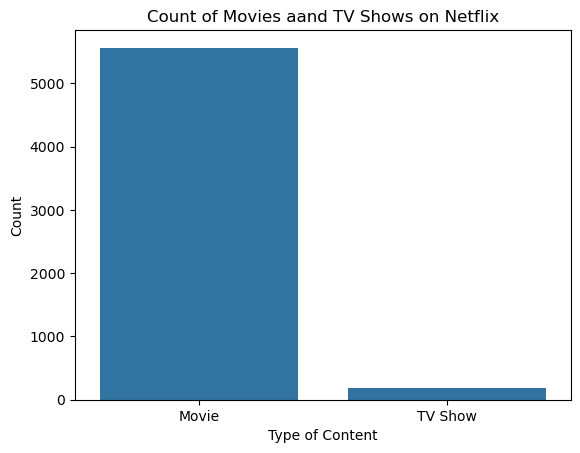

In [22]:
#Plot count of Movies vs TV Shows
sns.countplot(data=df,x='type')
plt.title('Count of Movies aand TV Shows on Netflix')
plt.xlabel('Type of Content')
plt.ylabel('Count')
plt.show()

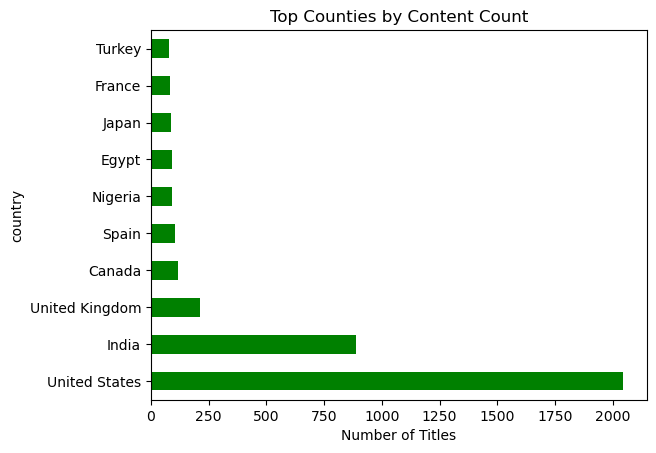

In [26]:
#Top 10 Countries by Number of Titles
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind = 'barh',title='Top Counties by Content Count', color = 'green')
plt.xlabel('Number of Titles')
plt.show()

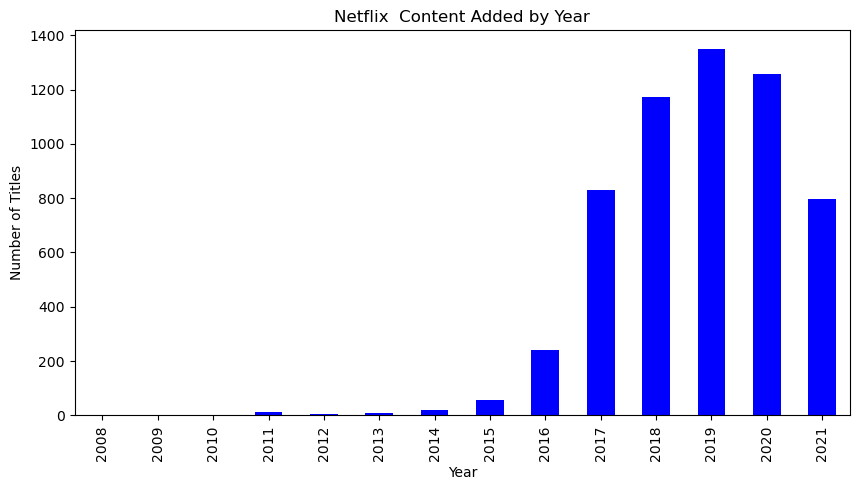

In [27]:
#Content added per year
df['year_added'].value_counts().sort_index().plot(kind='bar',figsize=(10,5),color = 'blue')
plt.title('Netflix  Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

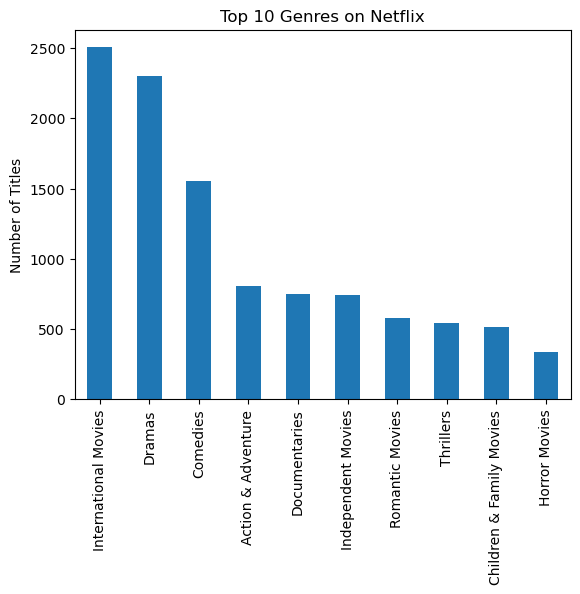

In [31]:
#Most frequent Genres
from collections import Counter
genres = []
for genre_list in df['listed_in']:
    genres.extend(genre_list.split(', '))
    
top_genres = pd.Series(Counter(genres)).sort_values(ascending=False).head(10)
top_genres.plot(kind = 'bar',title = 'Top 10 Genres on Netflix')
plt.ylabel('Number of Titles')
plt.show()

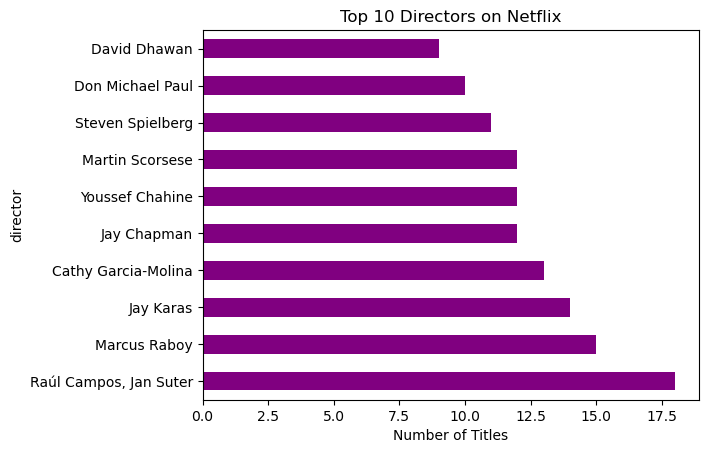

In [34]:
#Most Active directors on Netflix 
top_directors = df['director'].value_counts().head(10)
top_directors.plot(kind = 'barh',title = 'Top 10 Directors on Netflix', color = 'purple')
plt.xlabel('Number of Titles')
plt.show()